# Analyzing Model's Robustness and Generalization Across Data Overlap,Complexity and Noise

#**Research Questions:**

1. How do different classification algorithms perform on datasets with overlapping classes and complex decision boundaries? (Which machine learning algorithm works best on data with overlapping classes?)




# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
#import matplotlib
#matplotlib.use('TkAgg')  # or another interactive backend
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from matplotlib import cm
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from matplotlib import cm

In [ ]:
# Install Kaggle CLI
!pip install -q kaggle
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data
!unzip -q breast-cancer-wisconsin-data.zip


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open breast-cancer-wisconsin-data.zip, breast-cancer-wisconsin-data.zip.zip or breast-cancer-wisconsin-data.zip.ZIP.


# Q1 - Classifying Overlapping Classes

Research Question:

* How do different classification algorithms perform on datasets with overlapping classes and complex decision boundaries? (Which machine learning algorithm works best on data with overlapping classes?)


## Import Dataset
a kaggle dataset 'Breast cancer wisconsin dataset' given its relevance and suitability in medical classification tasks. it contains features based on biopsies each labeled as B (Benign) or M (Malignant)

we will use this datset to further test how differnet algorithms will perform on overlapping classes.

In [ ]:
data_url = "https://drive.google.com/uc?id=1pS2SkW4cWUFIxXUTlFUJzIf5gvnO5aSi"
df = pd.read_csv(data_url)
df.head(8)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN


## Exploratory Data Analysis

### Shape of Data
First, we check the shape of our data to know many examples (rows) and features (columns) we have

In [ ]:
print("The dataframe has {} rows and {} columns".format(df.shape[0], df.shape[1]))

The dataframe has 569 rows and 33 columns


### Inspect Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


**Observation:**
* remove 'Unnamed: 32' column
* diagnosis is label --> apply label encoding


### Data Distribution

* apply label encoding for the diagnosis column (label)
* check distribution for possible bias in the dataset

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

diagnosis
0    357
1    212
Name: count, dtype: int64


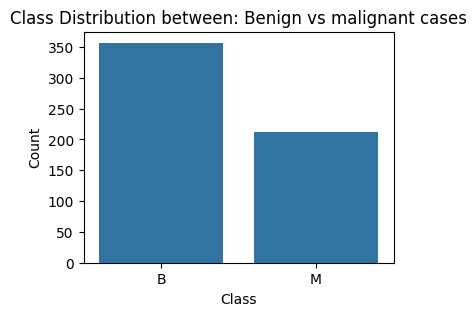

In [ ]:
class_count = df['diagnosis'].value_counts()
print(class_count)
names = {0: 'B', 1: 'M'}
plt.figure(figsize=(4, 3))
sns.barplot(x=class_count.index.map(names), y=class_count.values)
plt.title('Class Distribution between: Benign vs malignant cases')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Observation:**
* there appears to be an imbalance between the two classes. as there are more benign cases than malignant.
* to solve this matter, we will generate synthetic data using SMOTe techniqe to balance out the classes --- no gota generate a totally new synth dataset!

## Data Preprocesing

### Data Splitting
before preprocessig, we will perform data splitting to avoid data leakage and overfitting.

the split will be 60% training, 20% validation and 20% testing then the data is scaled to (mean=0 and standard deviation =1) to help the model learning process better and avoid potential feature dominance over the others due to larger values.

stratify paramter is used in the split to ensure balance of label distrbution amon the training and test sets (as much as possible).

In [ ]:
#drop unnamed as well!
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
y = df['diagnosis']

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=45 , stratify=y)


X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, stratify=y_train_full , random_state=42)

#scale afterwards
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


train label dist.: diagnosis
0    214
1    127
Name: count, dtype: int64
test label dist. diagnosis
0    72
1    42
Name: count, dtype: int64
Validation label dist. diagnosis
0    71
1    43
Name: count, dtype: int64


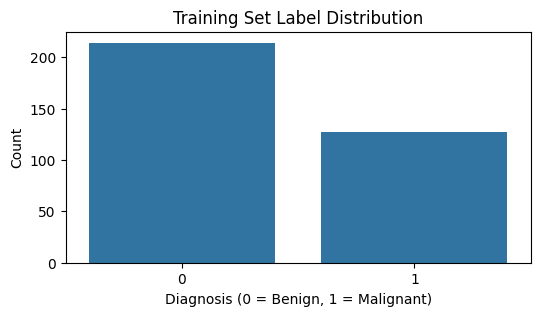

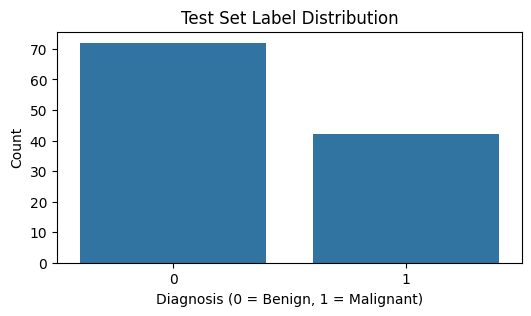

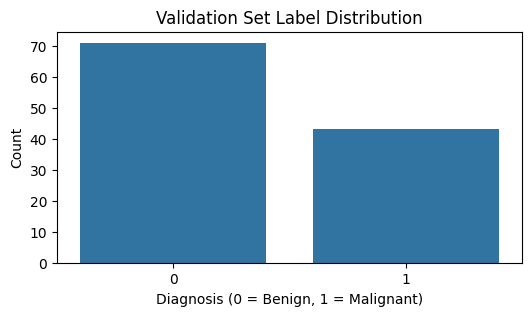

In [ ]:
print('train label dist.:', y_train.value_counts())
print('test label dist.',y_test.value_counts())
print('Validation label dist.',y_val.value_counts())

plt.figure(figsize=(6, 3))
sns.countplot(x=y_train)
plt.title('Training Set Label Distribution')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(6, 3))
sns.countplot(x=y_test)
plt.title('Test Set Label Distribution')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 3))
sns.countplot(x=y_val) #, palette='Set2'
plt.title('Validation Set Label Distribution')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()


**observation**
* data is moderately imbalanced after the split
* handle imbalance ? optional?

## Model Training

### Logistic Regression

The logistic regression model transforms the continuous output of linear regression into categorical output using a sigmoid function. it is a simple yet effective algorithm used for binary classification.

####Why Logistic Regression?

- Great for binary classification problems
- Interpretable: gives probabilities and a clear decision boundary
- Efficient on small-medium sized datasets
- Performs well when the relationship between features and class is approximately linear

####How It Works

Logistic Regression models the probability that a data point belongs to Class 1 using the logistic (sigmoid) function as see below:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

- $x$: feature vector  
- $w$: weights (learned from data)  
- $b$: bias (intercept)  
- Output: probability between 0 and 1


using decision rule:

- If  $P(y=1 \mid x) > 0.5$ --> predict **Class 1**
- If $P(y=1 \mid x) \leq 0.5$ --> predict **Class 0**

This creates a **linear decision boundary**:

$$
w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = 0
$$

- If the linear combination is greater than zero  $> 0$, the model predicts -->Class 1  
- If it is less than zero $< 0$ , the model predicts --> Class 0

To visualize how the classifier separates the two classes based on this boundary, we evaluate model predictions over a grid of feature values, holding other features fixed at their mean.

Lastly, logistic regression is well-suited for problems like breast cancer classification due to its simplicity, speed, and ability to output meaningful class probabilities.


In [ ]:
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train_scaled, y_train)

LogisticRegression()

confusion matrix
[[213   1]
 [  3 124]]


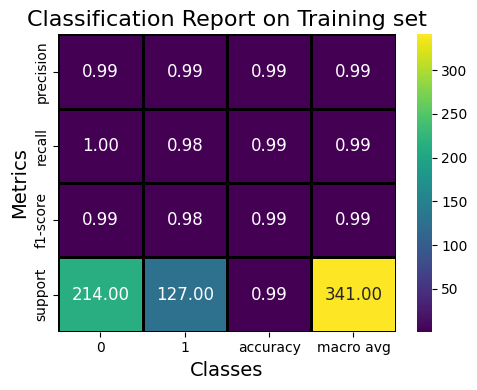


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       214
           1       0.99      0.98      0.98       127

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341

Training ROC-AUC: 0.9987489881521819
Training Log Loss: 0.045922456848722655


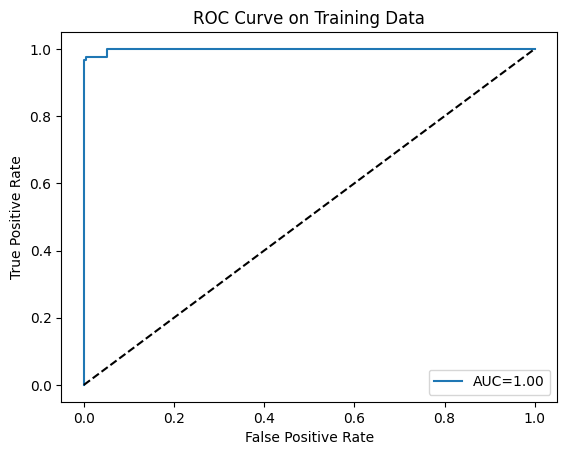

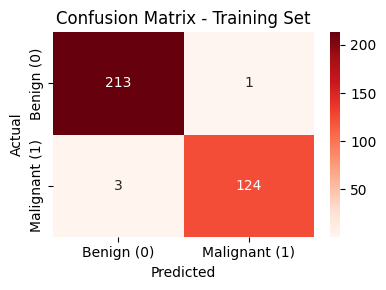

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, log_loss
import matplotlib.pyplot as plt

# Fit the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_train_scaled)
y_prob = model.predict_proba(X_train_scaled)[:, 1]  # probabilities for positive class
result_train = classification_report(y_train, y_pred,output_dict=True)

#print(classification_report(y_val, y_val_pred))
print('confusion matrix')
print(confusion_matrix(y_train, y_pred))


val_rs = pd.DataFrame(result_train).T
plt.figure(figsize=(5,4))
sns.heatmap(val_rs.iloc[:-1, :].T, annot=True, cmap="viridis", fmt='.2f', cbar=True,annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Classification Report on Training set', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()

# Metrics
print("\nClassification Report:\n", classification_report(y_train, y_pred))
print("Training ROC-AUC:", roc_auc_score(y_train, y_prob))
print("Training Log Loss:", log_loss(y_train, y_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_train, y_prob):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Training Data')
plt.legend()
plt.show()

# Visualize Confusion Matrix
cm = confusion_matrix(y_train, y_pred)
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Training Set')
plt.tight_layout()
plt.show()

#### Evaluation
we will evaluate the trained model on:

* Validation set → to estimate E_in (in- sample error)
* then apply hyper tuning to find the best parameters for a fair comparision
* Test set → to estimate E_out (out-of-sample error)

because by evaluating on validation and test sets, we can get an overview on model's generalizations capability and possible overfitting; which is cruicial for overlapping and complex boundaries.

TThe validation set performance after fitting acts as an estimate of the In-sample Error $E_in$ which is : $$E_in = 1 - accuracyOn Val set$$

while the test set performance measures the model’s ability on truly unseen data, representing $E_out$ where $$E_out = 1- accuracyOn Test set$$


## Hyper- Tuning:
- Find best params (like C, penalty)
- Re-train model with best params

where:

$$
L(w, b) = - \sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] + \lambda R(w)
$$

$
\text{where } \hat{y}_i = \sigma(w^T x_i + b) \text{ is the predicted probability via the sigmoid } \sigma,\text{and } R(w) \text{ is a regularization term to prevent overfitting.} $
$
\text{The hyperparameter } \lambda \text{ controls the strength of this regularization.}
$



and the regularization term R(w) =
\begin{cases}
\| w \|_2^2 = \sum_j w_j^2 & \text{for L2 regularization (Ridge)} \\
\| w \|_1 = \sum_j |w_j| & \text{for L1 regularization (Lasso)}
\end{cases}

$$
C = \frac{1}{\lambda}
$$

where

$$
\begin{cases}
\text{Large } C & \text{means less regularization (more complex model)} \\
\text{Small } C & \text{means more regularization (simpler model)}
\end{cases}
$$


confusion matrix
[[70  1]
 [ 3 40]]


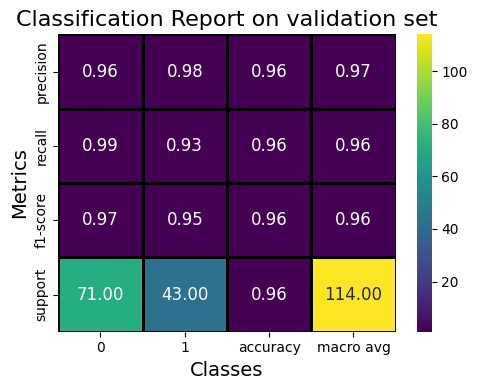

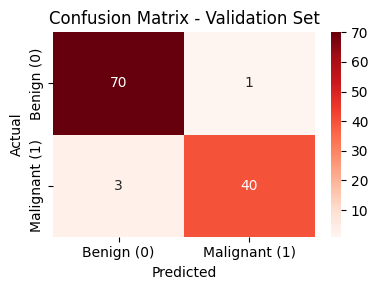

In [ ]:
y_val_pred = logistic_regression_model.predict(X_val_scaled)
result_val = classification_report(y_val, y_val_pred,output_dict=True)

#print(classification_report(y_val, y_val_pred))
print('confusion matrix')
print(confusion_matrix(y_val, y_val_pred))


val_rs = pd.DataFrame(result_val).T
plt.figure(figsize=(5,4))
sns.heatmap(val_rs.iloc[:-1, :].T, annot=True, cmap="viridis", fmt='.2f', cbar=True,annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Classification Report on validation set', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()


# Visualize Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()



In [ ]:
#hyper-tuning logreg on traiing and eval by val

#we used this ramge because it [0.01, 0.1, 1, 10, 100] spans small to large values to cover different regularization strengths broadly
logreg = LogisticRegression(max_iter=1000)
parameters = {'C': [0.01, 0.1, 1, 10, 100],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear']   }

searchingGrid = GridSearchCV(estimator=logreg, param_grid=parameters,cv=5, scoring='accuracy', verbose=1)
searchingGrid.fit(X_train_scaled, y_train)

print("Best Parameters:", searchingGrid.best_params_)
print("Best CV Accuracy:", searchingGrid.best_score_)

best_logreg = searchingGrid.best_estimator_
y_val_pred = best_logreg.predict(X_val_scaled)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.9794970161977835


**Observation**
after using hyper-tuning Grid search which automatically uses given to find the best values for the parameters to get ultimate model performance we got:
* **C = 0.1**
* **penalty using l2** --> ridge
* **solver using liblinear**

to achieve 97% accuracy


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[70  1]
 [ 2 41]]


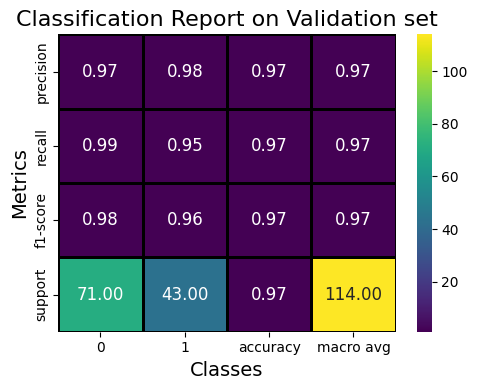

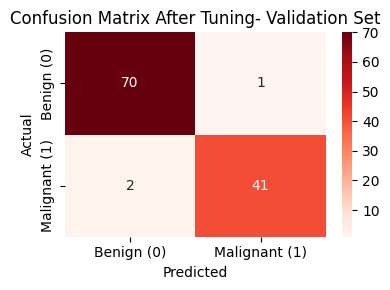

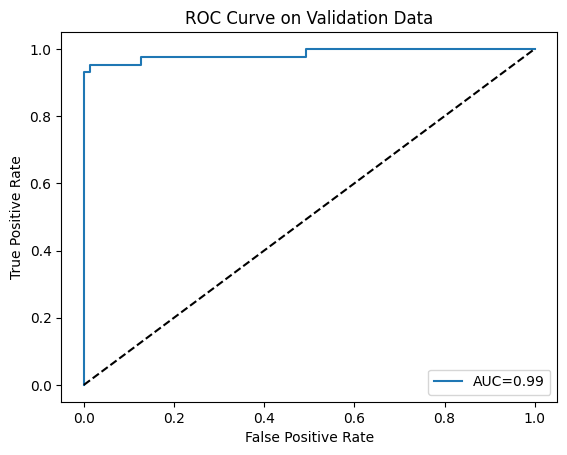

In [ ]:
#eval on val
y_val_pred = best_logreg.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_val_pred)
cr = classification_report(y_val, y_val_pred)

print("Classification Report:\n", cr)

result_tunedval = classification_report(y_val, y_val_pred, output_dict=True)
#print(result_tunedval)

sr = pd.DataFrame(result_tunedval).T
print(confusion_matrix(y_val, y_val_pred))

plt.figure(figsize=(5,4))
sns.heatmap(sr.iloc[:-1, :].T, annot=True, cmap="viridis", fmt='.2f', cbar=True,annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Classification Report on Validation set', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()


# Visualize Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix After Tuning- Validation Set')
plt.tight_layout()
plt.show()

# ROC Curve on validation data
y_prob = best_logreg.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = roc_auc_score(y_val, y_prob)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Validation Data')
plt.legend()
plt.show()

{'0': {'precision': 0.972972972972973, 'recall': 1.0, 'f1-score': 0.9863013698630136, 'support': 72.0}, '1': {'precision': 1.0, 'recall': 0.9523809523809523, 'f1-score': 0.975609756097561, 'support': 42.0}, 'accuracy': 0.9824561403508771, 'macro avg': {'precision': 0.9864864864864865, 'recall': 0.9761904761904762, 'f1-score': 0.9809555629802873, 'support': 114.0}, 'weighted avg': {'precision': 0.9829302987197724, 'recall': 0.9824561403508771, 'f1-score': 0.9823623542652152, 'support': 114.0}}
[[72  0]
 [ 2 40]]


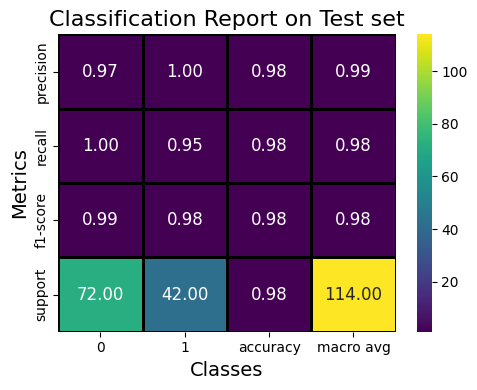

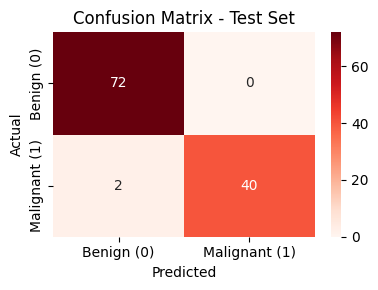

In [ ]:
#eval on test
best_logreg = searchingGrid.best_estimator_
y_predicted_tuned = best_logreg.predict(X_test_scaled)
result_tuned_test = classification_report(y_test, y_predicted_tuned, output_dict=True)
print(result_tuned_test)

sr = pd.DataFrame(result_tuned_test).T
print(confusion_matrix(y_test, y_predicted_tuned))

plt.figure(figsize=(5,4))
sns.heatmap(sr.iloc[:-1, :].T, annot=True, cmap="viridis", fmt='.2f', cbar=True,annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Classification Report on Test set', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()

# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_predicted_tuned)
labels = ['Benign (0)', 'Malignant (1)']

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

*Results:*
* **Validation** accuracy: 0.97 ( 3 FN, 1 FP )
* **Test** accuracy: 0.982 (2 FN, 0 FP)

* $E_in$ = 1 - 0.97 = 0.03 --> **3% error on validation**
* $E_out$ = 1 - 0.982=0.018 --> **1.8% error on Test**

This shows that our logistic regression model generalziaes well with no signs of over or under fitting as the test error remained low and close to the validation error after tuning



**Observation**

given the classification report on test, we see:
* the model is performing very well scoring 98%
* Only a couple of malignant cases were missed, which is minimal.
* however, we got high precision score so the predictions are reliable

#### Decision Boundary Visualization
**But Since the dataset has 30 features, we reduce dimensionality for 2D visualization (by testing) two approaches:**

1. Selecting the two (and three) most important features.  
2. Applying Principal Component Analysis (PCA) to extract two principal components.

20 radius_worst 1.1322261815954184
21 texture_worst 1.127779778304787
27 concave points_worst 1.0802148017355677


<Figure size 1000x600 with 0 Axes>

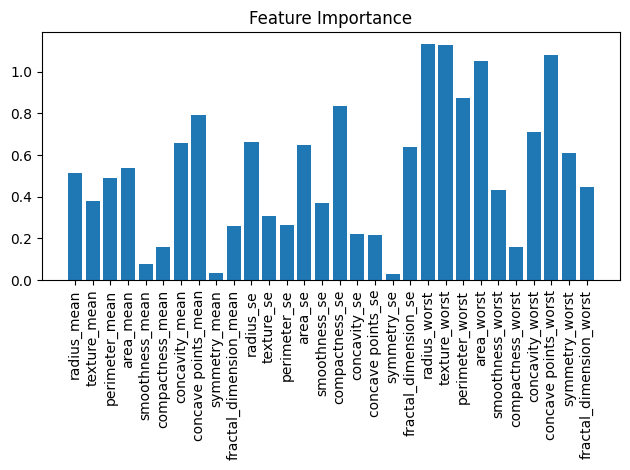

In [ ]:
coef = logistic_regression_model.coef_[0] #bes log
abs_coef = np.abs(coef)
features = X.columns
top3_idx = np.argsort(abs_coef)[-3:][::-1]
for i in top3_idx:
  print(i,features[i], abs_coef[i])


#print(abs_coef)
#features = [f'Feature {i}' for i in range(len(coef))]
plt.figure(figsize=(10,6))
plt.figure()
plt.bar(features, abs_coef)

plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.tight_layout()

plt.show()


this plot shows the feature importance upon classification by using the acquired coefficients after fitting the logistic regression model.

**we will take 2-3 out of the 30 features total to visualize the decision boundary and see if we can use it as a baseline to compare further. features selected are benchmark for this model and SVM (next) are: featureradius_worst, texture_worst and concave points_worst**

**why select features of highest importance?** because they contribute most to the model’s ability to separate classes, making them the best choices to visualize clear and meaningful decision boundaries.


Using the selected 2 and 3 features to visualize decision boundary: 
 



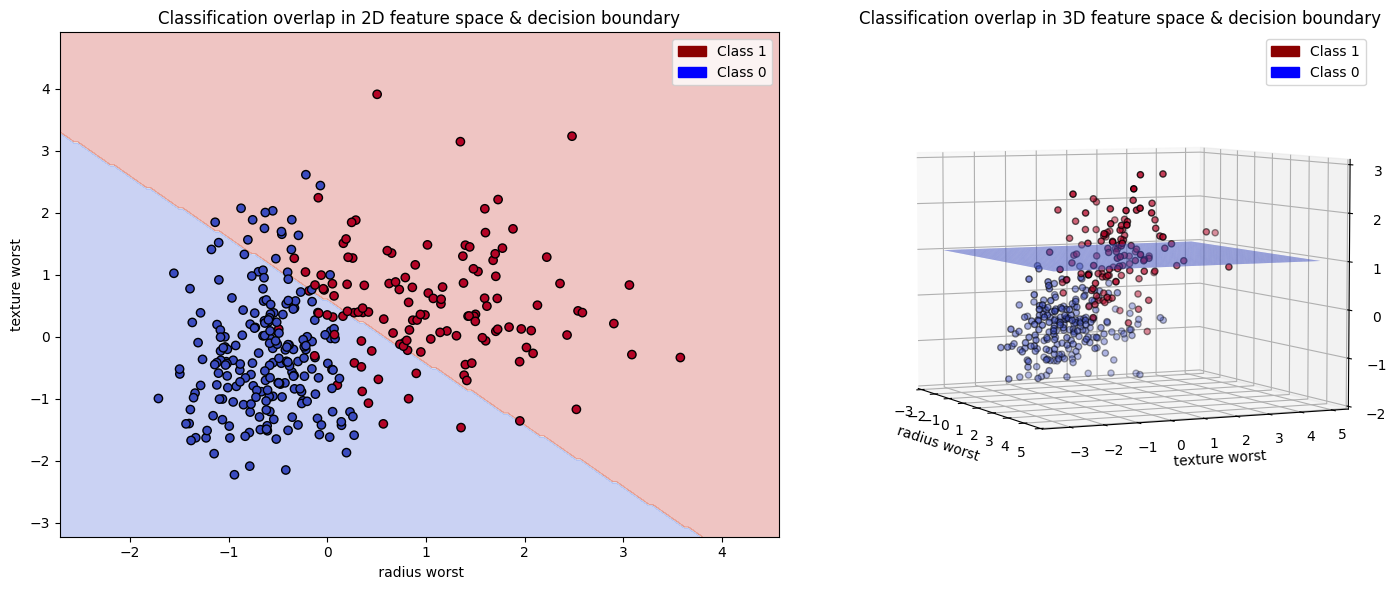

In [ ]:
print('Using the selected 2 and 3 features to visualize decision boundary: \n \n')

#plt.figure(figsize=(10,5))
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1, 2, 1)

# X_train[:, 10] is a 1d array of feature 10
#see it with boundaries clear -- use mesh grid
x_min, x_max = X_train_scaled[:, 20].min() - 1, X_train_scaled[:, 20].max() + 1
y_min, y_max = X_train_scaled[:, 21].min() - 1, X_train_scaled[:, 21].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),np.linspace(y_min, y_max, 200))

X_mesh = np.tile(X_train_scaled.mean(axis=0), (xx.ravel().shape[0], 1))
#replace values by mesh
X_mesh[:, 20] = xx.ravel()
X_mesh[:, 21] = yy.ravel()
from matplotlib import cm
Z = logistic_regression_model.predict(X_mesh)
Z = Z.reshape(xx.shape)

class_1 = mpatches.Patch(color='darkred', label='Class 1')
class_0 = mpatches.Patch(color='blue', label='Class 0')
#
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = ax1.scatter(X_train_scaled[:, 20], X_train_scaled[:, 21], c=y_train, cmap='coolwarm', edgecolors='k')
#plt.scatter(X_train[:, 10], X_train[:, 28], c=y_train, cmap='coolwarm', edgecolors='k')
ax1.set_xlabel(" radius worst")
ax1.set_ylabel("texture worst")
plt.title("Classification overlap in 2D feature space & decision boundary")
ax1.legend(handles=[class_1, class_0])


#now to show also 3d feat space
X_3d = X_train_scaled[:, [20,21,27]]
#z_min, z_max = X_train[:, 20].min() - 1, X_train[:, 20].max() + 1

x_min, x_max = X_3d[:, 0].min() - 1, X_3d[:, 0].max() + 1
y_min, y_max = X_3d[:, 1].min() - 1, X_3d[:, 1].max() + 1


xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
X_grd = np.tile(X_train.mean(axis=0), (xx.size, 1))
X_grd[:, 20] = xx.ravel()
X_grd[:, 21] = yy.ravel()

X_grd[:, 27] = np.mean(X_train_scaled[:, 27])
Z = logistic_regression_model.predict_proba(X_grd)[:,1]
Z = Z.reshape(xx.shape)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.view_init(elev=5, azim=335)
ax2.plot_surface(xx, yy, Z, cmap=cm.coolwarm, alpha=0.6)
contours = ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, offset=np.mean(X_train_scaled[:, 27]))
ax2.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_train, cmap='coolwarm', edgecolor='k')
ax2.set_xlabel(" radius worst")
ax2.set_ylabel("texture worst")
ax2.set_zlabel("concave points worst")
plt.title("Classification overlap in 3D feature space & decision boundary")
ax2.legend(handles=[class_1, class_0])
fig.subplots_adjust()
plt.tight_layout()
plt.show()

**In 2D**
* the classifier uses features 20 and 21
* mesh grid is used to overlaying actual data points of the features then the classifier predicts (.predict()) for each data point if it belongs to class 1 or 0 --> and thats how the decision boundary and overlapping cases are shown by colorig each case.
* note: .predict() gives a hard classification



**In 3D**
* same principle as before but here we use an extra feature 27, for z
* instead of prediction (2D) in 3D, we used probability (.predict-proba()) since it results in a more representable and smoother visualization of the boundary.(because probabiloty shows how sure the model is about the precited class)
* note: returns probabilities of confidence == smoother(not just 0 or 1)
* the decision boundary lies where the predicted probability equals 0.5

**Observation**
* the decision boundary of our model is linear
* we can clearly see that using logistic regression model, there appear to be overlapping cases between the two classes which would indicate False positive or false negative cases.

transformind data into PCA to visualize decision boundary: 
 



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


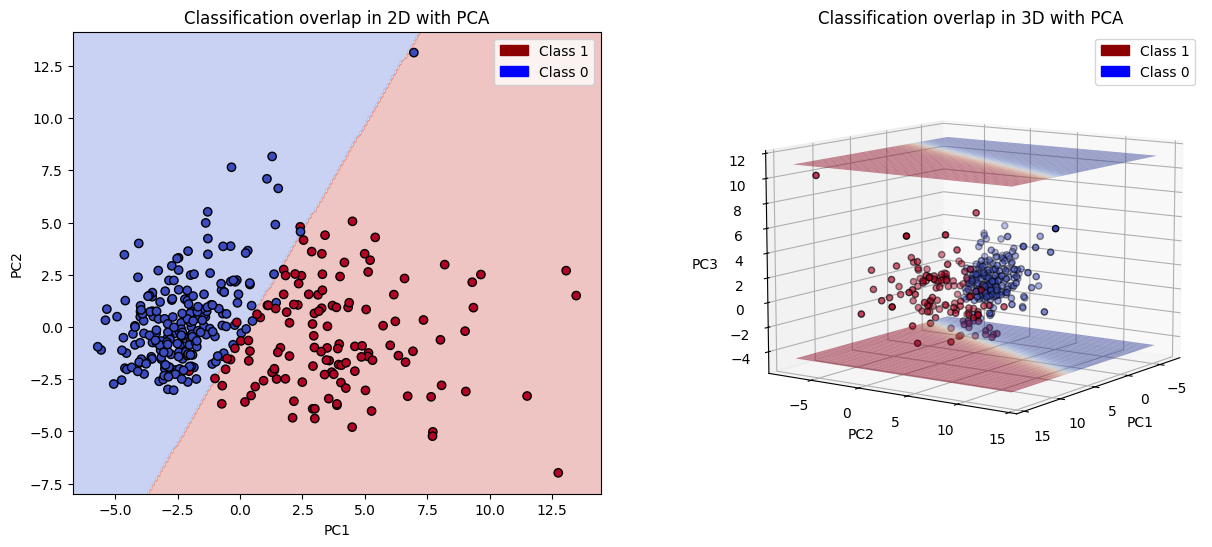

In [ ]:
#tuned + pca
print('transformind data into PCA to visualize decision boundary: \n \n')
pca_transform = PCA(n_components=2)
X_pca = pca_transform.fit_transform(X_train_scaled)

logreg_pca = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
logreg_pca.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = logreg_pca.predict(grid_points)
Z = Z.reshape(xx.shape)
class_1 = mpatches.Patch(color='darkred', label='Class 1')
class_0 = mpatches.Patch(color='blue', label='Class 0')

fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Classification overlap in 2D with PCA")
ax1.legend(handles=[class_1, class_0])
#plt.title("Classification overlap in 2D with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")


pca_transform_3 = PCA(n_components=3)
X_pca_3d = pca_transform_3.fit_transform(X_train_scaled)
logreg_pca3 = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
logreg_pca3.fit(X_pca_3d, y_train)

x_min, x_max = X_pca_3d[:, 0].min() - 1, X_pca_3d[:, 0].max() + 1
y_min, y_max = X_pca_3d[:, 1].min() - 1, X_pca_3d[:, 1].max() + 1
z_min, z_max = X_pca_3d[:, 2].min() - 1, X_pca_3d[:, 2].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
z_slices = np.linspace(z_min, z_max, 2)
ax2.view_init(elev=10, azim=35)
for z_val in z_slices:
    grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, z_val)]
    probs = logreg_pca3.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)
    surf = ax2.plot_surface(xx, yy, np.full_like(xx, z_val), facecolors=cm.coolwarm(probs), alpha=0.5, linewidth=0)

scatter = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y_train, cmap='coolwarm', edgecolor='k')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
plt.title('Classification overlap in 3D with PCA')
ax2.legend(handles=[class_1, class_0])
plt.show()


In [ ]:

explained = pca_transform.explained_variance_ratio_
total_explained = explained.sum()
print(f"Total variance preserved by 2 PCA components: {total_explained:.2%}")


Total variance preserved by 2 PCA components: 61.93%


**observation**
the first uses 2 principal components and shows overlap; but mostly near the decision boundary - unlike before

the second one visualized 3 Pcs and shows better how the boundary isnt separating the classes ideally.

**conclusion**
* Log reg is Simple and interpretable but limited with overlapping/nonlinear class boundaries.
* Even though the top two important features overlap when viewed alone, the model leverages multiple features together—captured well by PCA components—to find an effective decision boundary. This highlights that feature importance reflects combined predictive power, not standalone class separation
* The dataset shows soft overlapping near the decision boundary which highlights how relevant this case is of real-world data

### Support Vector Machine
SVM is a supervised learning algorithm used for classification and regression. It finds the optimal hyperplane that maximizes the margin between classes. here we aim to maximize the margin around the decision boundary to prevent overlapping using SVm with kermel trick


Given training data $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$, where $y_i \in \{-1, +1\}$, solve:

 $$
\min_{\mathbf{w}, b, \xi} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^N \xi_i$$


subject to:

$$
y_i \left( \sum_{j=1}^N \alpha_j y_j K(\mathbf{x}_j, \mathbf{x}_i) + b \right) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

where $alpha_j$ are Lagrange multipliers, $xi_i$ are slack variables, and $C$ is the penalty parameter.


**RBF Kernel:**
$$
K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2 \right)$$

- gamma controls the kernel width highergamma = tighter fit
- it maps data into infinite dimensional space to handle complex boundaries


#### Evaluation

=== Training Set Evaluation ===
[[213   1]
 [  4 123]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       214
           1       0.99      0.97      0.98       127

    accuracy                           0.99       341
   macro avg       0.99      0.98      0.98       341
weighted avg       0.99      0.99      0.99       341



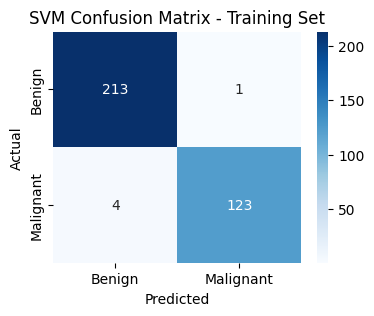

=== Validation Set Evaluation ===
[[67  4]
 [ 2 41]]
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        71
           1       0.91      0.95      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



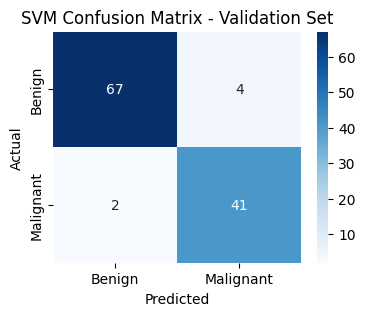

In [ ]:
# Train SVM
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)

# ==== Training set evaluation ====
y_train_pred = svm_model.predict(X_train_scaled)
print("=== Training Set Evaluation ===")
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

# Plot confusion matrix for training set
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Training Set')
plt.show()

# ==== Validation set evaluation ====
y_val_pred = svm_model.predict(X_val_scaled)
print("=== Validation Set Evaluation ===")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# Plot confusion matrix for validation set
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Validation Set')
plt.show()



In [ ]:
##hypertune svm

param_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True), param_svm, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score: 0.9736146632566071


[[70  1]
 [ 3 40]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



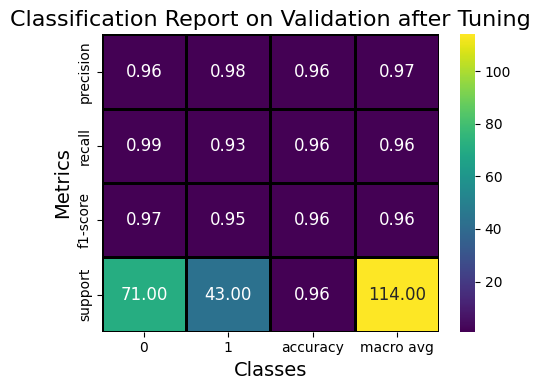

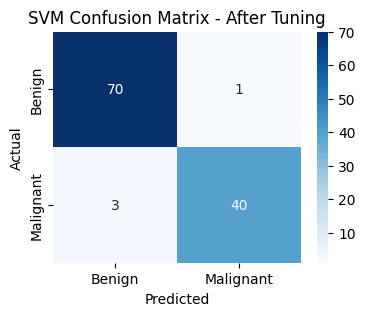

In [ ]:
#testing on validation after tunning
#on val
best_svm = SVC(kernel='rbf', C=10, gamma=0.001, probability=True)
best_svm.fit(X_train_scaled, y_train)

y_valpred = best_svm.predict(X_val_scaled)

print(confusion_matrix(y_val, y_valpred))
print(classification_report(y_val, y_valpred))

result2 = classification_report(y_val, y_valpred, output_dict=True)
sr2 = pd.DataFrame(result2).T

plt.figure(figsize=(5,4))
sns.heatmap(sr2.iloc[:-1, :].T, annot=True, cmap="viridis", fmt='.2f', cbar=True,
            annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Classification Report on Validation after Tuning', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_val, y_valpred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - After Tuning')
plt.show()

test aAccuracy: 0.9824561403508771
Confusion matrix:
 [[72  0]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



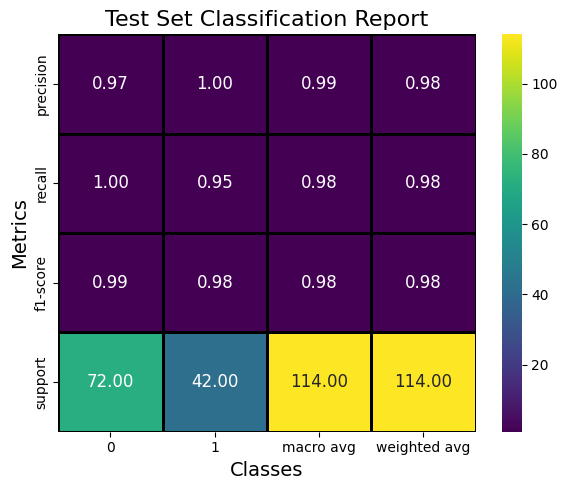

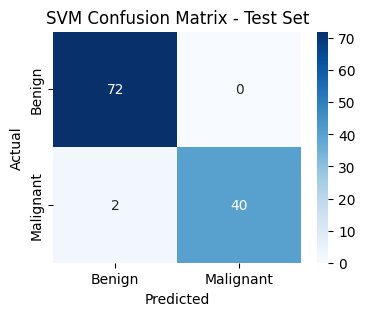

In [ ]:
#testing on test set after being tuned
best_svm = grid.best_estimator_
y_test_pred = best_svm.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("test aAccuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))



result2 = classification_report(y_test, y_test_pred, output_dict=True)

sr2 = pd.DataFrame(result2).T
sr2_filtered = sr2.drop(index='accuracy')

plt.figure(figsize=(6,5))
sns.heatmap(sr2_filtered.T, annot=True, cmap="viridis", fmt='.2f', cbar=True,
            annot_kws={'size': 12}, linewidths=1, linecolor='black')

plt.title('Test Set Classification Report', fontsize=16)
plt.ylabel('Metrics', fontsize=14)
plt.xlabel('Classes', fontsize=14)
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix - Test Set')
plt.show()


on validation set:
* accuracy of 96%
* 4 misclassifications
* overall, shows SVM to be a good model with a balanced performance

on test (after tuning):
* Accuracy of 98% is great and higher than validation
* 2 misclassified samples out of 114 total

*Results:*
* **Validation** accuracy: 0.96 ( 3 FN, 1 FP )
* **Test** accuracy: 0.9912 (2 FN, 0 FP)

* $E_in$ = 1 - 0.96 = 0.04 --> **4% error on validation**
* $E_out$ = 1 - 0.98 = 0.02 --> **2% error on Test**












<!--The model’s validation performance (Ein) demonstrates strong accuracy (96%) with very good precision and recall, indicating effective training and tuning. The even better test performance (Eout) at 98% accuracy confirms excellent generalization to unseen data, with no significant overfitting. The close Ein and Eout values highlight the reliability of the SVM with RBF kernel in handling this classification task..-->



**Observation**
SVM shows good generalization with higher precision and recall,suggesting the soft margin RBF kernel tuning improved the decision boundary. The model handles the class imbalance and overlap well after tuning.

The soft boundary of SVM with RBF kernelwhen when is properly tuned allows flexible decision boundaries that capture the data distribution better, reducing misclassifications compared to before tuning.




#### Decision Boundary Visualization

<ipython-input-66-4bd3cf00bfc2>:22: UserWarning: The following kwargs were not used by contour: 'color'
  contour = plt.contour(xx, yy, Z, levels=[0], linewidths=1 ,color='k')


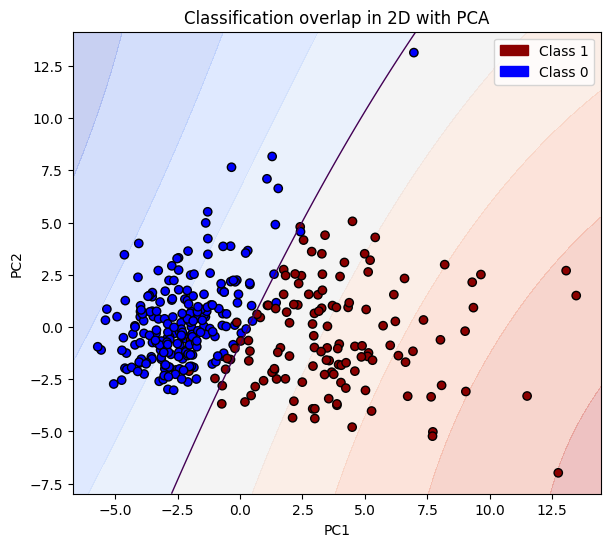

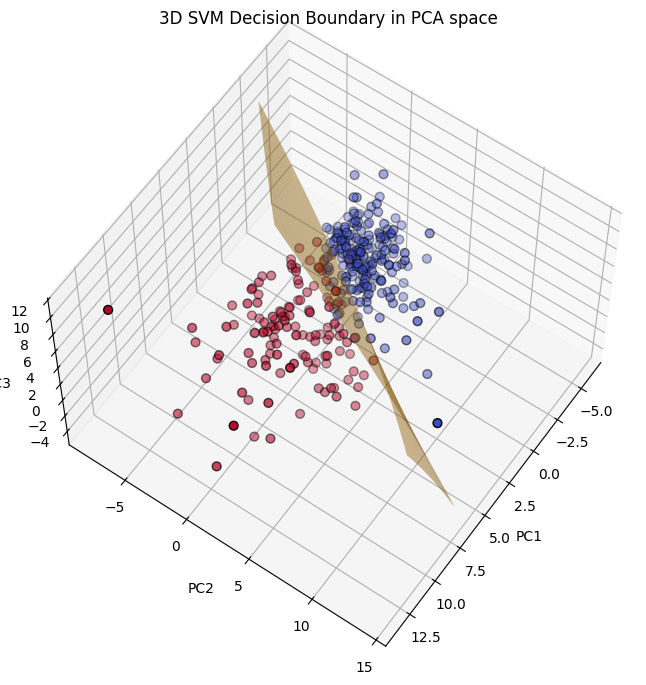

In [ ]:

#svmpca = SVC(kernel='rbf', probability=True)

svmpca = SVC(kernel='rbf', probability=True, C=10, gamma=0.001)
svmpca.fit(X_pca, y_train)

from matplotlib.colors import ListedColormap


x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svmpca.decision_function(grid_points)
Z = Z.reshape(xx.shape)
class_1 = mpatches.Patch(color='darkred', label='Class 1')
class_0 = mpatches.Patch(color='blue', label='Class 0')

fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
contour = plt.contour(xx, yy, Z, levels=[0], linewidths=1 ,color='k')


#plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=ListedColormap(['blue', 'darkred']), edgecolors='k')
plt.title("Classification overlap in 2D with PCA")
ax1.legend(handles=[class_1, class_0])
#plt.title("Classification overlap in 2D with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
from skimage import measure


#svm_3d = SVC(kernel='rbf', probability=True)
svm_3d = SVC(kernel='rbf', probability=True, C=10, gamma=0.001)
svm_3d.fit(X_pca_3d, y_train)

x_min, x_max = X_pca_3d[:, 0].min() - 1, X_pca_3d[:, 0].max() + 1
y_min, y_max = X_pca_3d[:, 1].min() - 1, X_pca_3d[:, 1].max() + 1
z_min, z_max = X_pca_3d[:, 2].min() - 1, X_pca_3d[:, 2].max() + 1

xx, yy, zz = np.mgrid[x_min:x_max:50j, y_min:y_max:50j, z_min:z_max:50j]
grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

Z = svm_3d.decision_function(grid_points)
Z = Z.reshape(xx.shape)

verts, faces, normals, values = measure.marching_cubes(Z, level=0)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

verts[:, 0] = verts[:, 0] * (x_max - x_min) / 49 + x_min
verts[:, 1] = verts[:, 1] * (y_max - y_min) / 49 + y_min
verts[:, 2] = verts[:, 2] * (z_max - z_min) / 49 + z_min

mesh = ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], color='orange', alpha=0.5)
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y_train, cmap='coolwarm', edgecolor='k', s=40)
ax.view_init(elev=60, azim=35)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("3D SVM Decision Boundary in PCA space")
plt.show()

**obervation**
usiing SVM, the decision boundary is non-linear and flexible especially given we're using the kernel trick. However, the results are similar to logistic regression not a significant improvement.

**2D:**

* The SVM shows a much sharper margin, with a more defined division between classes.
* The boundary may be non-linear, depending on the kernel used (likely RBF or polynomial).
* There appears to be less overlap between classes compared to logistic regression—SVM is better at maximizing the margin.

**3D:**
* The decision surface in 3D is more complex—not just a flat plane
* Tis suggests that SVM is capturing non-linear patterns in the data
* You can see class separation along all 3 PCA components and the surface bend slightly.

## **Conclusion**

**Final Comparison**

eventhough the dataset isnt with an agressive overlappig like a spiral or XOR dataset would, however, it was interesting to see how real life datasets that are sensitive to misclassifications in the medical field would be affected per model. however, we need to note that the dataset is not considered big and that has its own limitations gicen the tricky boundary.

**Value of 2D and 3D Visualization:**
Plotting in 2D gave simple view of class overlap while the 3D PCA plot exposed how the data is distributed in a more complex way. Using both helped understand boundary behavior and how models handle overlapping regions better.


as a final result, after applying PCA and tuning both logistic regression and SVM, we can say that:
<br>

1. **Performance:**

based on both results, log regression model and SVM are both well-tuned with no overfitting but SVM performs slightly better than Log regression on the test set showing that it generalizes better on unseen data

2. **Visualizations:**
logistic regression drew a linear hyperplane which works well due to the structure of our data but is less flexible with overlapping or non-linear data. while the RBF kernel in svm allowed the decision surface to bend as needed to fit the data handling more complex and overlapping distributions

3. **PCA vs. Top Feature Selection:**
PCA outperformed top 2 –3 feature selection in both tested scenarios of Logistic Regression:(1) using only top features directly, and (2) plotting decision boundaries with them.Since Logistic Regression depends on the combined linear influence of all features, PCAs ability to preserve overall variance led to better separation and performance.

*Answer:*
thus, based on both quantitative results and decision boundary visualizations, SVM with RBF kernel performs better than Logistic Regression in handling overlapping classes and complex boundaries. Future studies could explore other models or test on larger datasets to further validate these findings.
